<h3>Title and Objective</h3>


In [ ]:
# Phishing Website Detection - Data Cleaning and Preprocessing
# Objective: To preprocess the phishing website dataset by performing data cleaning and transformation steps such as missing value handling, duplicate removal, outlier treatment, encoding, scaling, and train-test splitting so that the dataset can be used effectively for machine learning model training.

<h3>Load Dataset and Basic Inspection</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display

df = pd.read_csv("../data/dataset_full.csv")

print("Shape:", df.shape)
display(df.head())
display(df.tail())
df.info()
display(df.describe().T)

Shape: (88647, 112)


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
88642,3,1,0,0,0,0,0,0,0,0,...,1,3,1,3597,0,0,0,0,0,0
88643,2,0,0,0,0,0,0,0,0,0,...,1,2,2,591,0,2,0,0,0,0
88644,2,1,0,5,0,0,0,0,0,0,...,1,2,5,14391,1,0,0,0,0,1
88645,2,0,0,1,0,0,0,0,0,0,...,1,1,1,52,1,0,0,0,0,1
88646,2,0,0,0,0,0,0,0,0,0,...,1,4,0,299,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88647 entries, 0 to 88646
Columns: 112 entries, qty_dot_url to phishing
dtypes: float64(1), int64(111)
memory usage: 75.7 MB


,count,mean,std,min,25%,50%,75%,max
qty_dot_url,88647.0,2.191343,1.235636,1.0,2.0,2.0,2.0,24.0
qty_hyphen_url,88647.0,0.328810,1.119286,0.0,0.0,0.0,0.0,35.0
qty_underline_url,88647.0,0.113879,0.657767,0.0,0.0,0.0,0.0,21.0
qty_slash_url,88647.0,1.281781,1.893929,0.0,0.0,0.0,2.0,44.0
qty_questionmark_url,88647.0,0.009329,0.112568,0.0,0.0,0.0,0.0,9.0
...,...,...,...,...,...,...,...,...
qty_redirects,88647.0,0.343903,0.783892,-1.0,0.0,0.0,1.0,17.0
url_google_index,88647.0,0.001410,0.058640,-1.0,0.0,0.0,0.0,1.0
domain_google_index,88647.0,0.002019,0.063250,-1.0,0.0,0.0,0.0,1.0
url_shortened,88647.0,0.005482,0.073841,0.0,0.0,0.0,0.0,1.0


<h3> Clean Column Names </h3>

In [2]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns.tolist()

['qty_dot_url',
 'qty_hyphen_url',
 'qty_underline_url',
 'qty_slash_url',
 'qty_questionmark_url',
 'qty_equal_url',
 'qty_at_url',
 'qty_and_url',
 'qty_exclamation_url',
 'qty_space_url',
 'qty_tilde_url',
 'qty_comma_url',
 'qty_plus_url',
 'qty_asterisk_url',
 'qty_hashtag_url',
 'qty_dollar_url',
 'qty_percent_url',
 'qty_tld_url',
 'length_url',
 'qty_dot_domain',
 'qty_hyphen_domain',
 'qty_underline_domain',
 'qty_slash_domain',
 'qty_questionmark_domain',
 'qty_equal_domain',
 'qty_at_domain',
 'qty_and_domain',
 'qty_exclamation_domain',
 'qty_space_domain',
 'qty_tilde_domain',
 'qty_comma_domain',
 'qty_plus_domain',
 'qty_asterisk_domain',
 'qty_hashtag_domain',
 'qty_dollar_domain',
 'qty_percent_domain',
 'qty_vowels_domain',
 'domain_length',
 'domain_in_ip',
 'server_client_domain',
 'qty_dot_directory',
 'qty_hyphen_directory',
 'qty_underline_directory',
 'qty_slash_directory',
 'qty_questionmark_directory',
 'qty_equal_directory',
 'qty_at_directory',
 'qty_and_dir

<h3>Check Missing Values</h3>

In [3]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

display(missing_count.sort_values(ascending=False))
display(missing_percent.sort_values(ascending=False))

qty_dot_url             0
qty_hyphen_url          0
qty_underline_url       0
qty_slash_url           0
qty_questionmark_url    0
                       ..
qty_redirects           0
url_google_index        0
domain_google_index     0
url_shortened           0
phishing                0
Length: 112, dtype: int64

qty_dot_url             0.0
qty_hyphen_url          0.0
qty_underline_url       0.0
qty_slash_url           0.0
qty_questionmark_url    0.0
                       ... 
qty_redirects           0.0
url_google_index        0.0
domain_google_index     0.0
url_shortened           0.0
phishing                0.0
Length: 112, dtype: float64

<h3>Handle Missing Values</h3>

In [4]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

<h3>Remove Duplicate Rows</h3>

In [5]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

Duplicate rows before: 1438
Duplicate rows after: 0


<h3>Separate Features and Target</h3>

In [6]:
target_col = "phishing"

X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87209, 111)
y shape: (87209,)


<h3>Check Class Balance</h3>

phishing
0    56712
1    30497
Name: count, dtype: int64
phishing
0    65.029985
1    34.970015
Name: proportion, dtype: float64


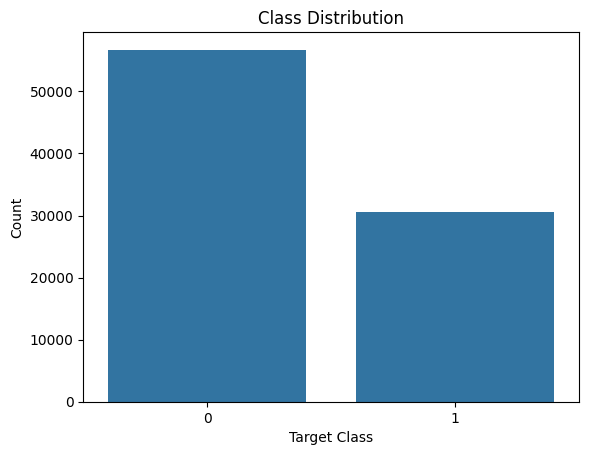

In [7]:
print(y.value_counts())
print((y.value_counts(normalize=True) * 100))

sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.show()

<h3>Check Categorical Columns</h3>

In [8]:
cat_cols = X.select_dtypes(include="object").columns
print("Categorical columns:", list(cat_cols))

Categorical columns: []


<h3>Encode Categorcal Variables If Any</h3>

In [9]:
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape after encoding:", X.shape)

Shape after encoding: (87209, 111)


<h3> Visualize Important Phishing Features </h3>

Important columns found: ['length_url', 'qty_redirects', 'qty_dot_url', 'qty_at_url', 'url_shortened']


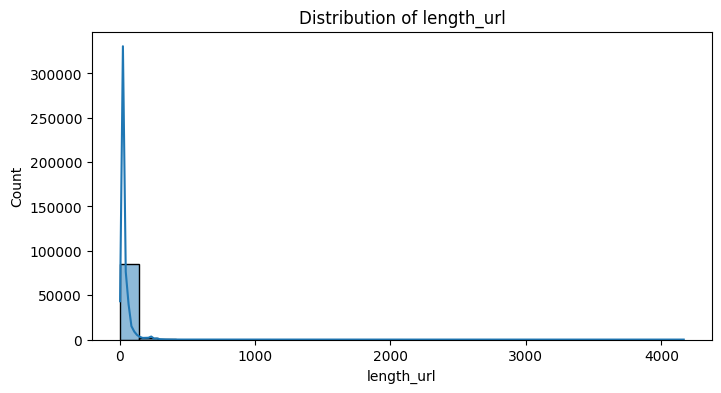

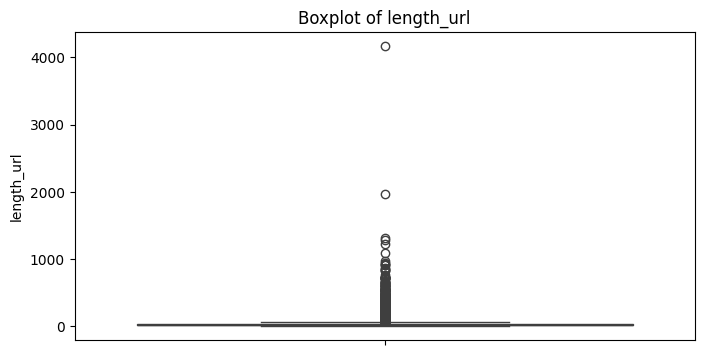

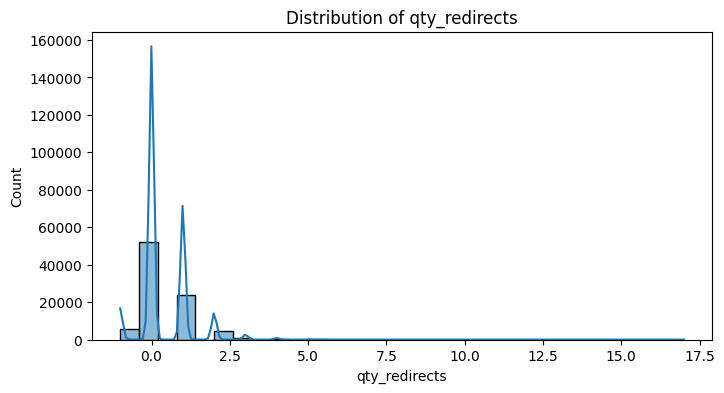

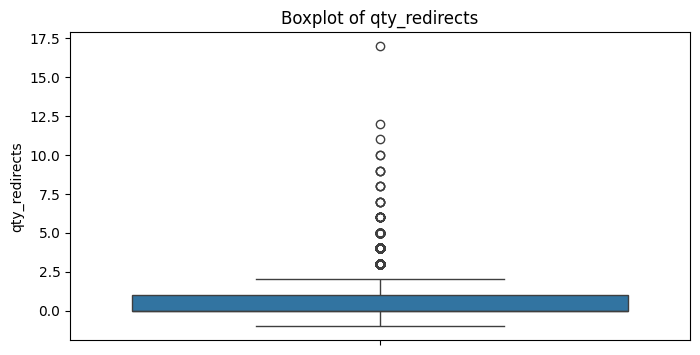

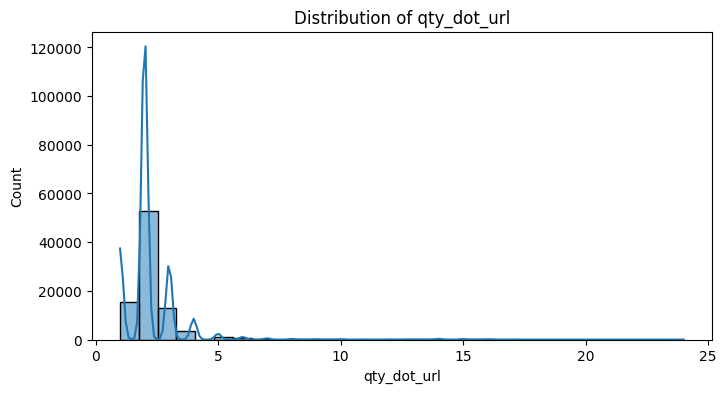

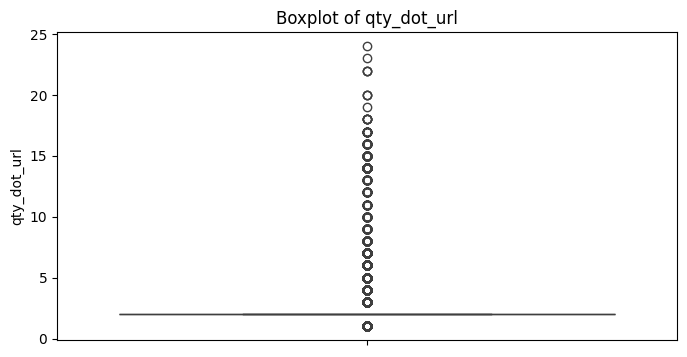

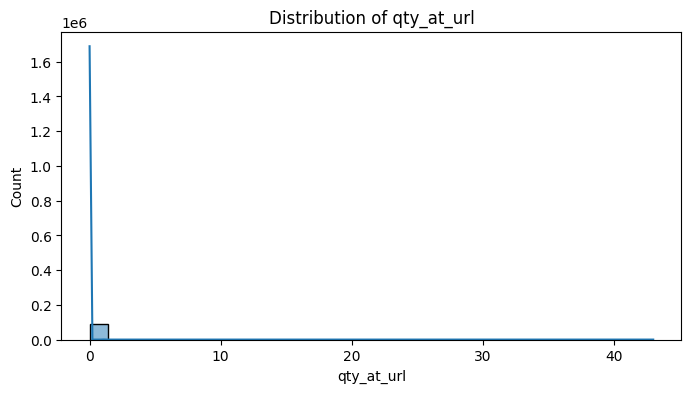

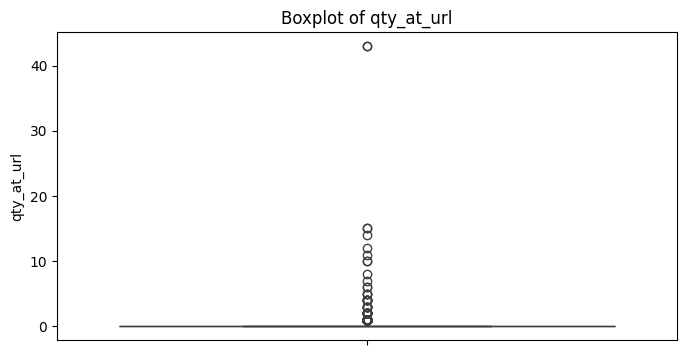

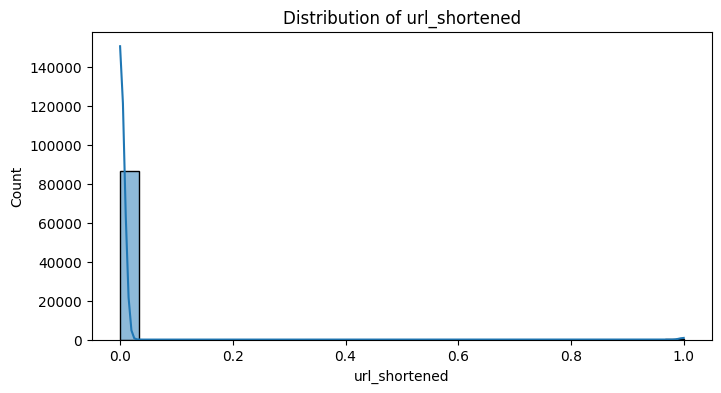

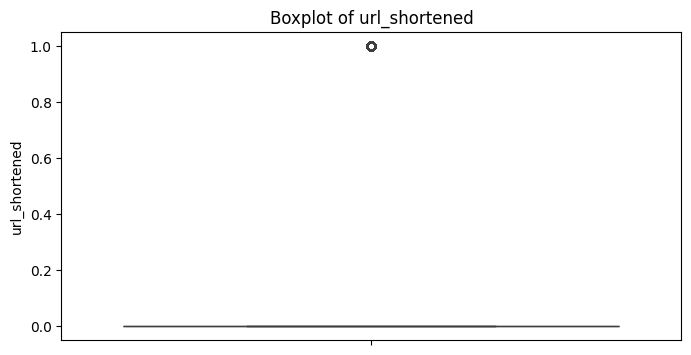

In [10]:
important_cols = [
    col for col in ["length_url", "qty_redirects", "qty_dot_url", "qty_at_url", "url_shortened"]
    if col in df.columns
]

print("Important columns found:", important_cols)

for col in important_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

<h3> Handle Outliers </h3>

In [12]:
for col in important_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_bound, upper_bound)

<h3> Train-Test Split </h3>

In [13]:
X = df.drop(columns=[target_col])
y = df[target_col]

if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (69767, 111)
X_test shape: (17442, 111)
y_train shape: (69767,)
y_test shape: (17442,)


<h3> Scale Numeric Features </h3>

In [14]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,time_domain_expiration,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened
51629,0.0,-0.293449,-0.176439,-0.683314,-0.08192,-0.215436,0.0,-0.152853,-0.033643,-0.013833,...,0.892528,-0.200055,-0.577996,-0.450195,0.079213,0.970465,-0.493772,-0.02726,-0.037674,0.0
78231,0.0,-0.293449,-0.176439,-0.154650,-0.08192,2.915888,0.0,2.011792,-0.033643,-0.013833,...,0.584290,-0.200055,0.940838,1.891644,-0.530866,0.970465,-0.493772,-0.02726,-0.037674,0.0
83432,0.0,-0.293449,-0.176439,-0.683314,-0.08192,-0.215436,0.0,-0.152853,-0.033643,-0.013833,...,-0.156477,0.958799,-0.577996,-0.450195,-0.507758,0.970465,0.895440,-0.02726,-0.037674,0.0
71284,0.0,-0.293449,-0.176439,-0.154650,-0.08192,-0.215436,0.0,-0.152853,-0.033643,-0.013833,...,5.148210,-0.200055,-0.577996,-0.450195,-0.529762,0.970465,-0.493772,-0.02726,-0.037674,0.0
40057,0.0,-0.293449,-0.176439,-0.683314,-0.08192,-0.215436,0.0,-0.152853,-0.033643,-0.013833,...,0.488172,-0.200055,-0.577996,1.891644,0.384295,0.970465,-0.493772,-0.02726,-0.037674,0.0


<h3> Save Cleaned Dataset </h3>

In [15]:
df.to_csv("../data/cleaned_phishing_dataset.csv", index=False)
X_train_scaled.to_csv("../data/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("../data/X_test_scaled.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

## Final Summary

- Dataset was loaded successfully.
- Column names were cleaned.
- Missing values were checked and handled.
- Duplicate rows were removed.
- Class balance was checked.
- Important phishing-related features were visualized.
- Outliers were clipped where needed.
- Categorical variables were encoded if present.
- Numeric features were scaled after splitting.
- Cleaned data is now ready for model training.